In [1]:
import logging

logger = logging.getLogger(__name__)

import counterfactual_graph_generation
from counterfactual_graph_generation.data.make_dataset import CounterfactualGraphDataModule
from matplotlib import pyplot as plt
from collections import Counter
from omegaconf import OmegaConf

### A notebook with the purpose of visulizing statistics on the preprocessed graphs
def get_data_module(cfg):
    logger.info("Load data module, prepare- and setup data...")
    data_module = CounterfactualGraphDataModule(**cfg)
    data_module.prepare_data()
    data_module.setup()
    return data_module

In [6]:

aids_config = OmegaConf.load('../config/dataset/aids.yaml')
mutagenicity_config = OmegaConf.load('../config/dataset/mutagenicity.yaml')
nci1_config = OmegaConf.load('../config/dataset/nci1.yaml')
proteins_config = OmegaConf.load('../config/dataset/proteins.yaml')
ogbg_molhiv_config = OmegaConf.load('../config/dataset/ogbg-molhiv.yaml')

config = ogbg_molhiv_config

In [7]:
dm = get_data_module(config)
dm.setup()

Downloaded 0.00 GB: 100%|██████████| 3/3 [00:03<00:00,  1.03s/it]
Processing...


Extracting data/ogb-molhiv/sparse/hiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 41127/41127 [00:00<00:00, 85072.97it/s] 


Converting graphs into PyG objects...


100%|██████████| 41127/41127 [00:01<00:00, 26304.24it/s]


Saving...


Done!


Train dataset size:  32901
Validation dataset size:  4113
Test dataset size:  4113
Total size:  41127
Number of node attributes:  9
Has edge attributes?  True
Number of edge attributes:  3


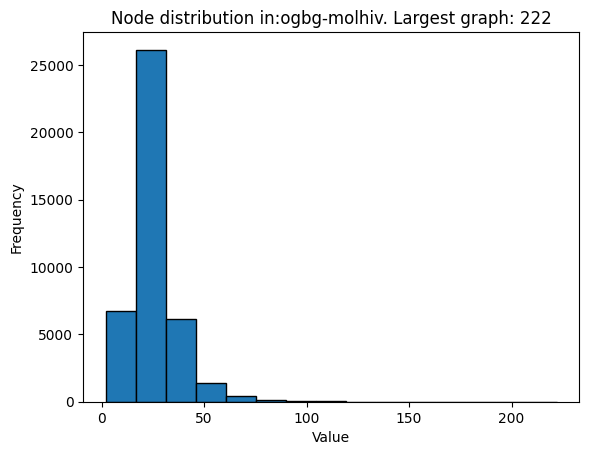

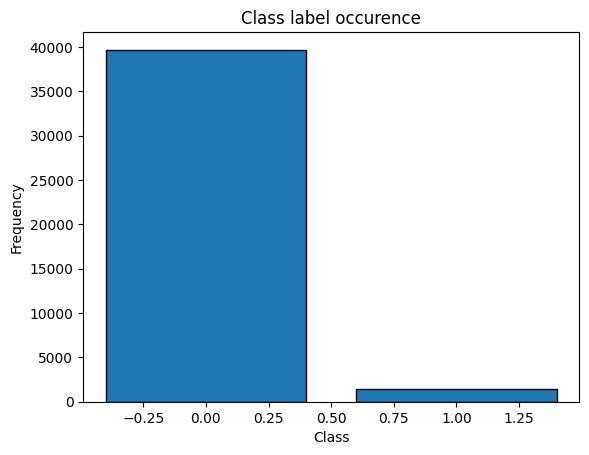

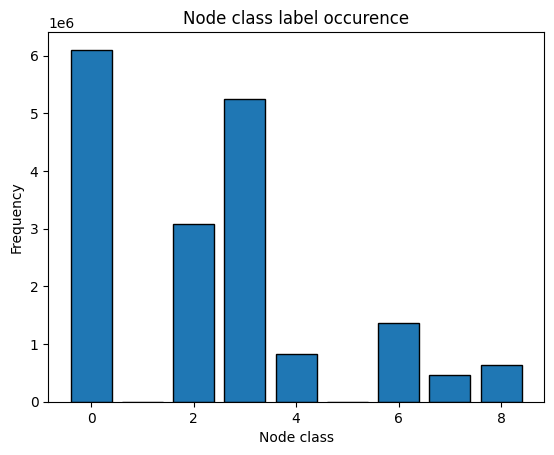

In [8]:
# Size of dataset:
print("Train dataset size: ", len(dm.data_train))
print("Validation dataset size: ", len(dm.data_val))
print("Test dataset size: ", len(dm.data_test))
print("Total size: ",  len(dm.dataset))

# Find number of node attributes
print("Number of node attributes: ", dm.dataset[0].x.shape[1])
has_edge_attributes = dm.dataset[0].edge_attr != None
print("Has edge attributes? ", has_edge_attributes)
if has_edge_attributes:
    print("Number of edge attributes: ", dm.dataset[0].edge_attr.shape[1])

# Find largest graph in dataset
max_num_nodes = 0
num_nodes = []
all_labels = []
node_label_frequencies = None
for _, graph in enumerate(dm.dataset):
    max_num_nodes = max(graph.x.shape[0], max_num_nodes)
    num_nodes.append(graph.x.shape[0])
    all_labels.append(graph.y.item())
    if node_label_frequencies != None:
        node_label_frequencies += graph.x.sum(dim=0)
    else:
        node_label_frequencies = graph.x.sum(dim=0)

# Plot distribution
title = "Node distribution in:" + config['dataset_name'] + ". Largest graph: " + str(max(num_nodes))
xlabel = "Value"
ylabel = "Frequency"
plt.hist(num_nodes, bins=15, edgecolor='black')
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.show()

# Show the distribution between different classes
counter = Counter(all_labels)
labels, frequencies = zip(*counter.items())
title = "Class label occurence"
xlabel = "Class"
ylabel = "Frequency"
plt.bar(labels, frequencies, edgecolor='black')
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.show()

# Node label distribution:
title = "Node class label occurence"
xlabel = "Node class"
ylabel = "Frequency"
plt.bar(range(len(node_label_frequencies)), node_label_frequencies, edgecolor='black')
plt.title(title)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.show()

In [10]:
ds = dm.data_train


In [43]:
s = [(ds[i].x[:,0] < 1).sum() for i in range(32000)]

In [41]:
z = []
for i, item in enumerate(s):
    if item > 0:
        z.append(item)


In [42]:
z

[]